In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats
import itertools

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
# Reduce data frame to config ids at 5%, 10%, ..., 100% performance per environment and algorithm
reduced_data = pd.DataFrame()
for env in envs:
    for algo in algos:
        subset = data[(data["env_name"] == env) & (data["algorithm"] == algo)]
        if subset.empty:
            continue
        
        for percentile in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]:
            target_performance = subset[subset["training_steps"]==subset["training_steps"].max()]["performance"].quantile(percentile)
            sort_by_closest = subset.iloc[(subset["performance"]-target_performance).abs().argsort()]
            config_id = sort_by_closest[sort_by_closest["training_steps"]==subset["training_steps"].max()]["config_id"].values[0]
            rows_to_keep = subset[subset["config_id"] == config_id]
            rows_to_keep["percentile"] = percentile
            reduced_data = pd.concat([reduced_data, rows_to_keep])

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_89151/3521271597.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rows_to_keep["percentile"] = percentile
/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_89151/3521271597.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rows_to_keep["percentile"] = percentile
/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_89151/3521271597.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

In [4]:
reduced_data.head()

,config_id,training_steps,performance,hp_config.clip_eps,hp_config.ent_coef,hp_config.gae_lambda,hp_config.learning_rate,hp_config.max_grad_norm,hp_config.minibatch_size,hp_config.normalize_advantage,...,hp_config.learning_starts,hp_config.target_epsilon,hp_config.use_target_network,hp_config.buffer_alpha,hp_config.buffer_beta,hp_config.buffer_epsilon,hp_config.target_update_interval,hp_config.reward_scale,hp_config.tau,percentile
2520,252,1000000.0,1468.750,0.141757,0.131539,0.866668,0.000727,0.89487,128.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05
2521,252,2000000.0,3234.375,0.141757,0.131539,0.866668,0.000727,0.89487,128.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05
2522,252,3000000.0,6546.875,0.141757,0.131539,0.866668,0.000727,0.89487,128.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05
2523,252,4000000.0,0.000,0.141757,0.131539,0.866668,0.000727,0.89487,128.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05
2524,252,5000000.0,0.000,0.141757,0.131539,0.866668,0.000727,0.89487,128.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05


/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_89151/3543203391.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr = stats.spearmanr(budget_performance, final_performance).correlation


<Axes: xlabel='budget_fraction', ylabel='spearman_correlation'>

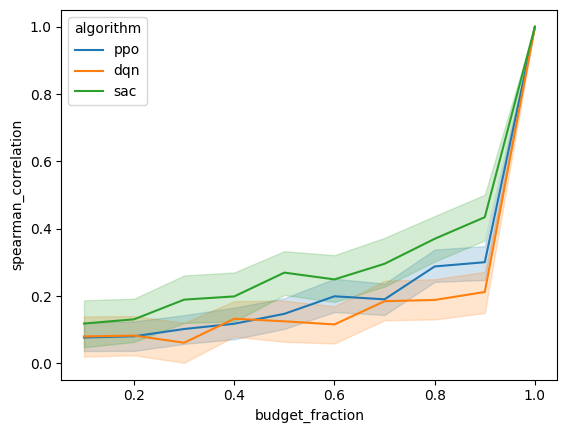

In [5]:
environments = []
algorithms = []
budgets = []
correlations = []
config_ids = []
percentiles = []
for env in envs:
    for algo in algos:
        subset = reduced_data[(reduced_data["env_name"] == env) & (reduced_data["algorithm"] == algo)]
        if subset.empty:
            continue
        
        for config_id in subset["config_id"].unique():
            config_data = subset[subset["config_id"] == config_id]
            full_budget = config_data["training_steps"].max()
            for budget in config_data["training_steps"].unique():
                budget_data = config_data[config_data["training_steps"] <= budget]
                budget_performance = budget_data[budget_data["training_steps"]==budget_data["training_steps"].max()]["performance"].values
                final_performance = config_data[config_data["training_steps"]==config_data["training_steps"].max()]["performance"].values
                spearman_corr = stats.spearmanr(budget_performance, final_performance).correlation
                    
                environments.append(env)
                algorithms.append(algo)
                budgets.append(budget/full_budget)
                correlations.append(spearman_corr)
                config_ids.append(config_id)
                percentiles.append(config_data["percentile"].values[0])

budget_corr_data = pd.DataFrame({
    "env_name": environments,
    "algorithm": algorithms,
    "budget_fraction": budgets,
    "spearman_correlation": correlations,
    "config_id": config_ids,
    "percentile": percentiles
})
sns.lineplot(data=budget_corr_data, x="budget_fraction", y="spearman_correlation", hue="algorithm")
# sns.relplot(data=budget_corr_data, x="budget_fraction", y="spearman_correlation", hue="algorithm", kind="line", col="env_name", col_wrap=4)

In [6]:
budget_corr_data.head()

,env_name,algorithm,budget_fraction,spearman_correlation,config_id,percentile
0,atari_battle_zone,ppo,0.1,-0.220575,252,0.05
1,atari_battle_zone,ppo,0.2,-0.207600,252,0.05
2,atari_battle_zone,ppo,0.3,-0.078087,252,0.05
3,atari_battle_zone,ppo,0.4,-0.289572,252,0.05
4,atari_battle_zone,ppo,0.5,0.144938,252,0.05


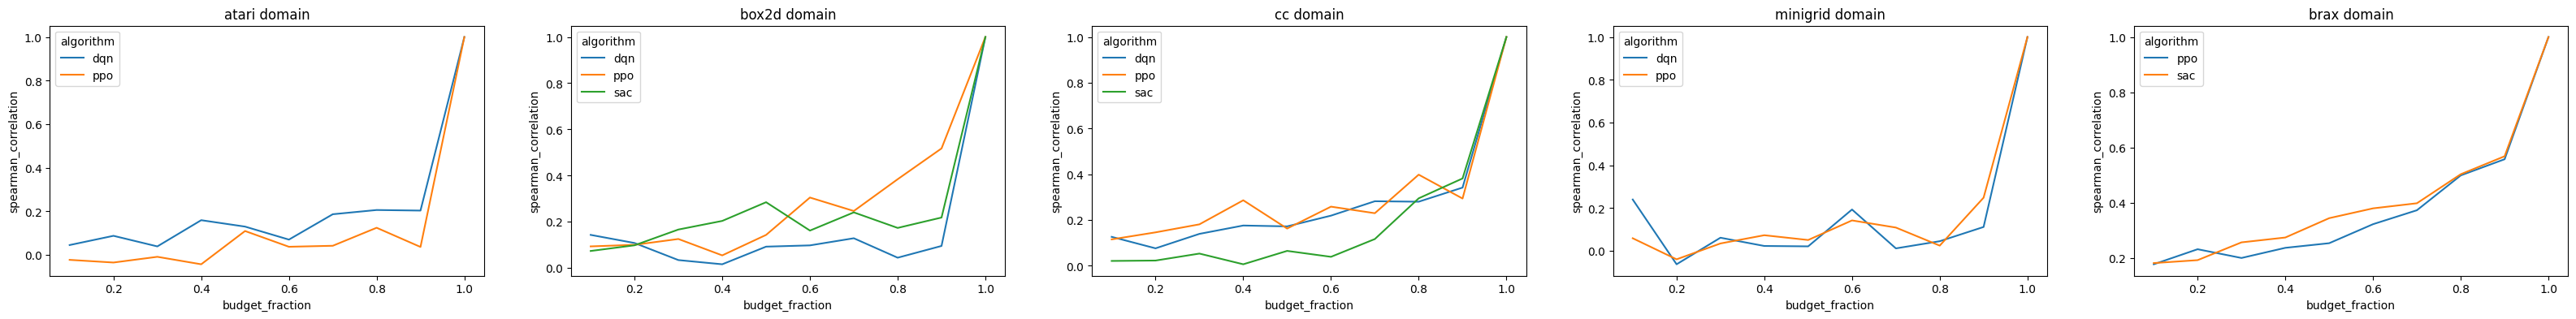

In [7]:
domains = ["atari", "box2d", "cc", "minigrid", "brax"]
fig, ax = plt.subplots(1, len(domains), figsize=(8*len(domains), 4))
for i, domain in enumerate(domains):
    domain_data = budget_corr_data[budget_corr_data["env_name"].str.contains(domain)]
    avg_corr = domain_data.groupby(["algorithm", "budget_fraction"])["spearman_correlation"].mean().reset_index()
    sns.lineplot(data=avg_corr, x="budget_fraction", y="spearman_correlation", hue="algorithm", ax=ax[i]).set(title=f"{domain} domain")

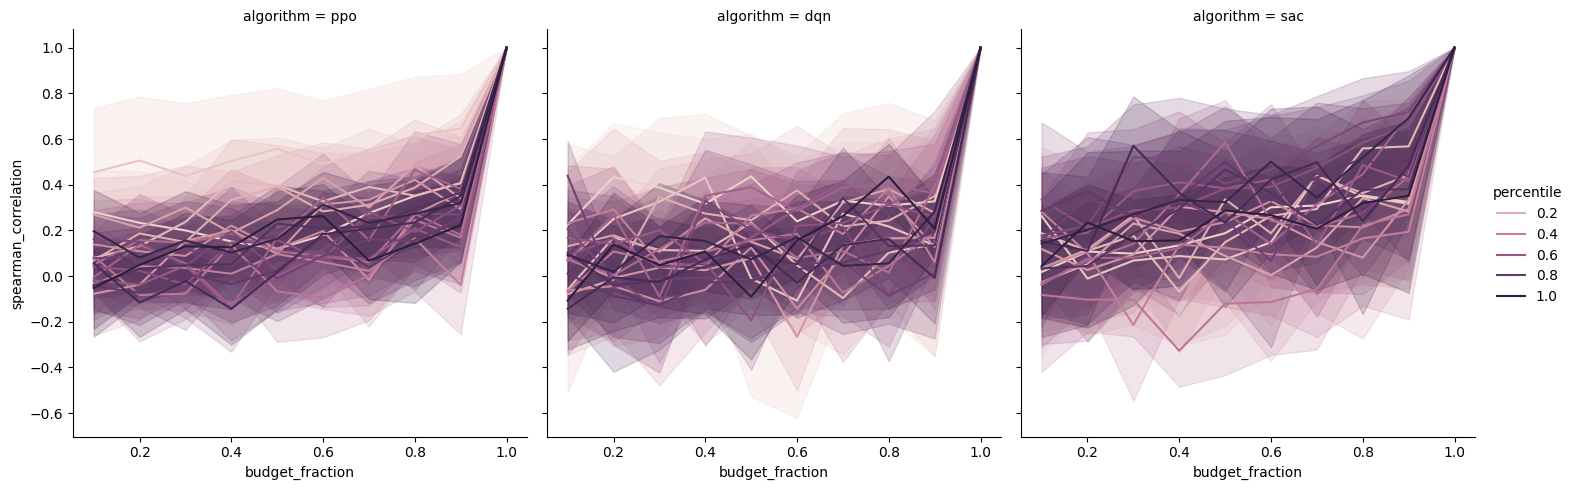

In [8]:
sns.relplot(data=budget_corr_data, x="budget_fraction", y="spearman_correlation", kind="line", col="algorithm", hue="percentile")

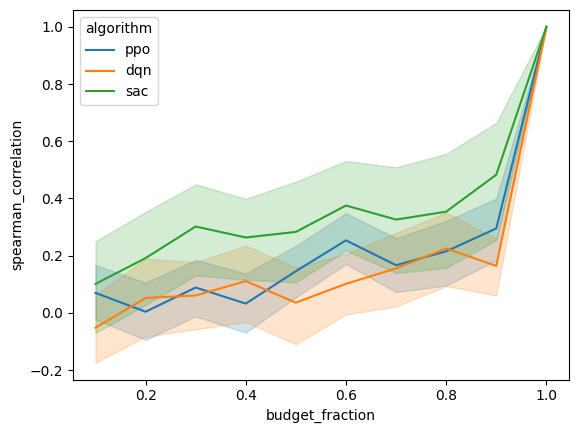

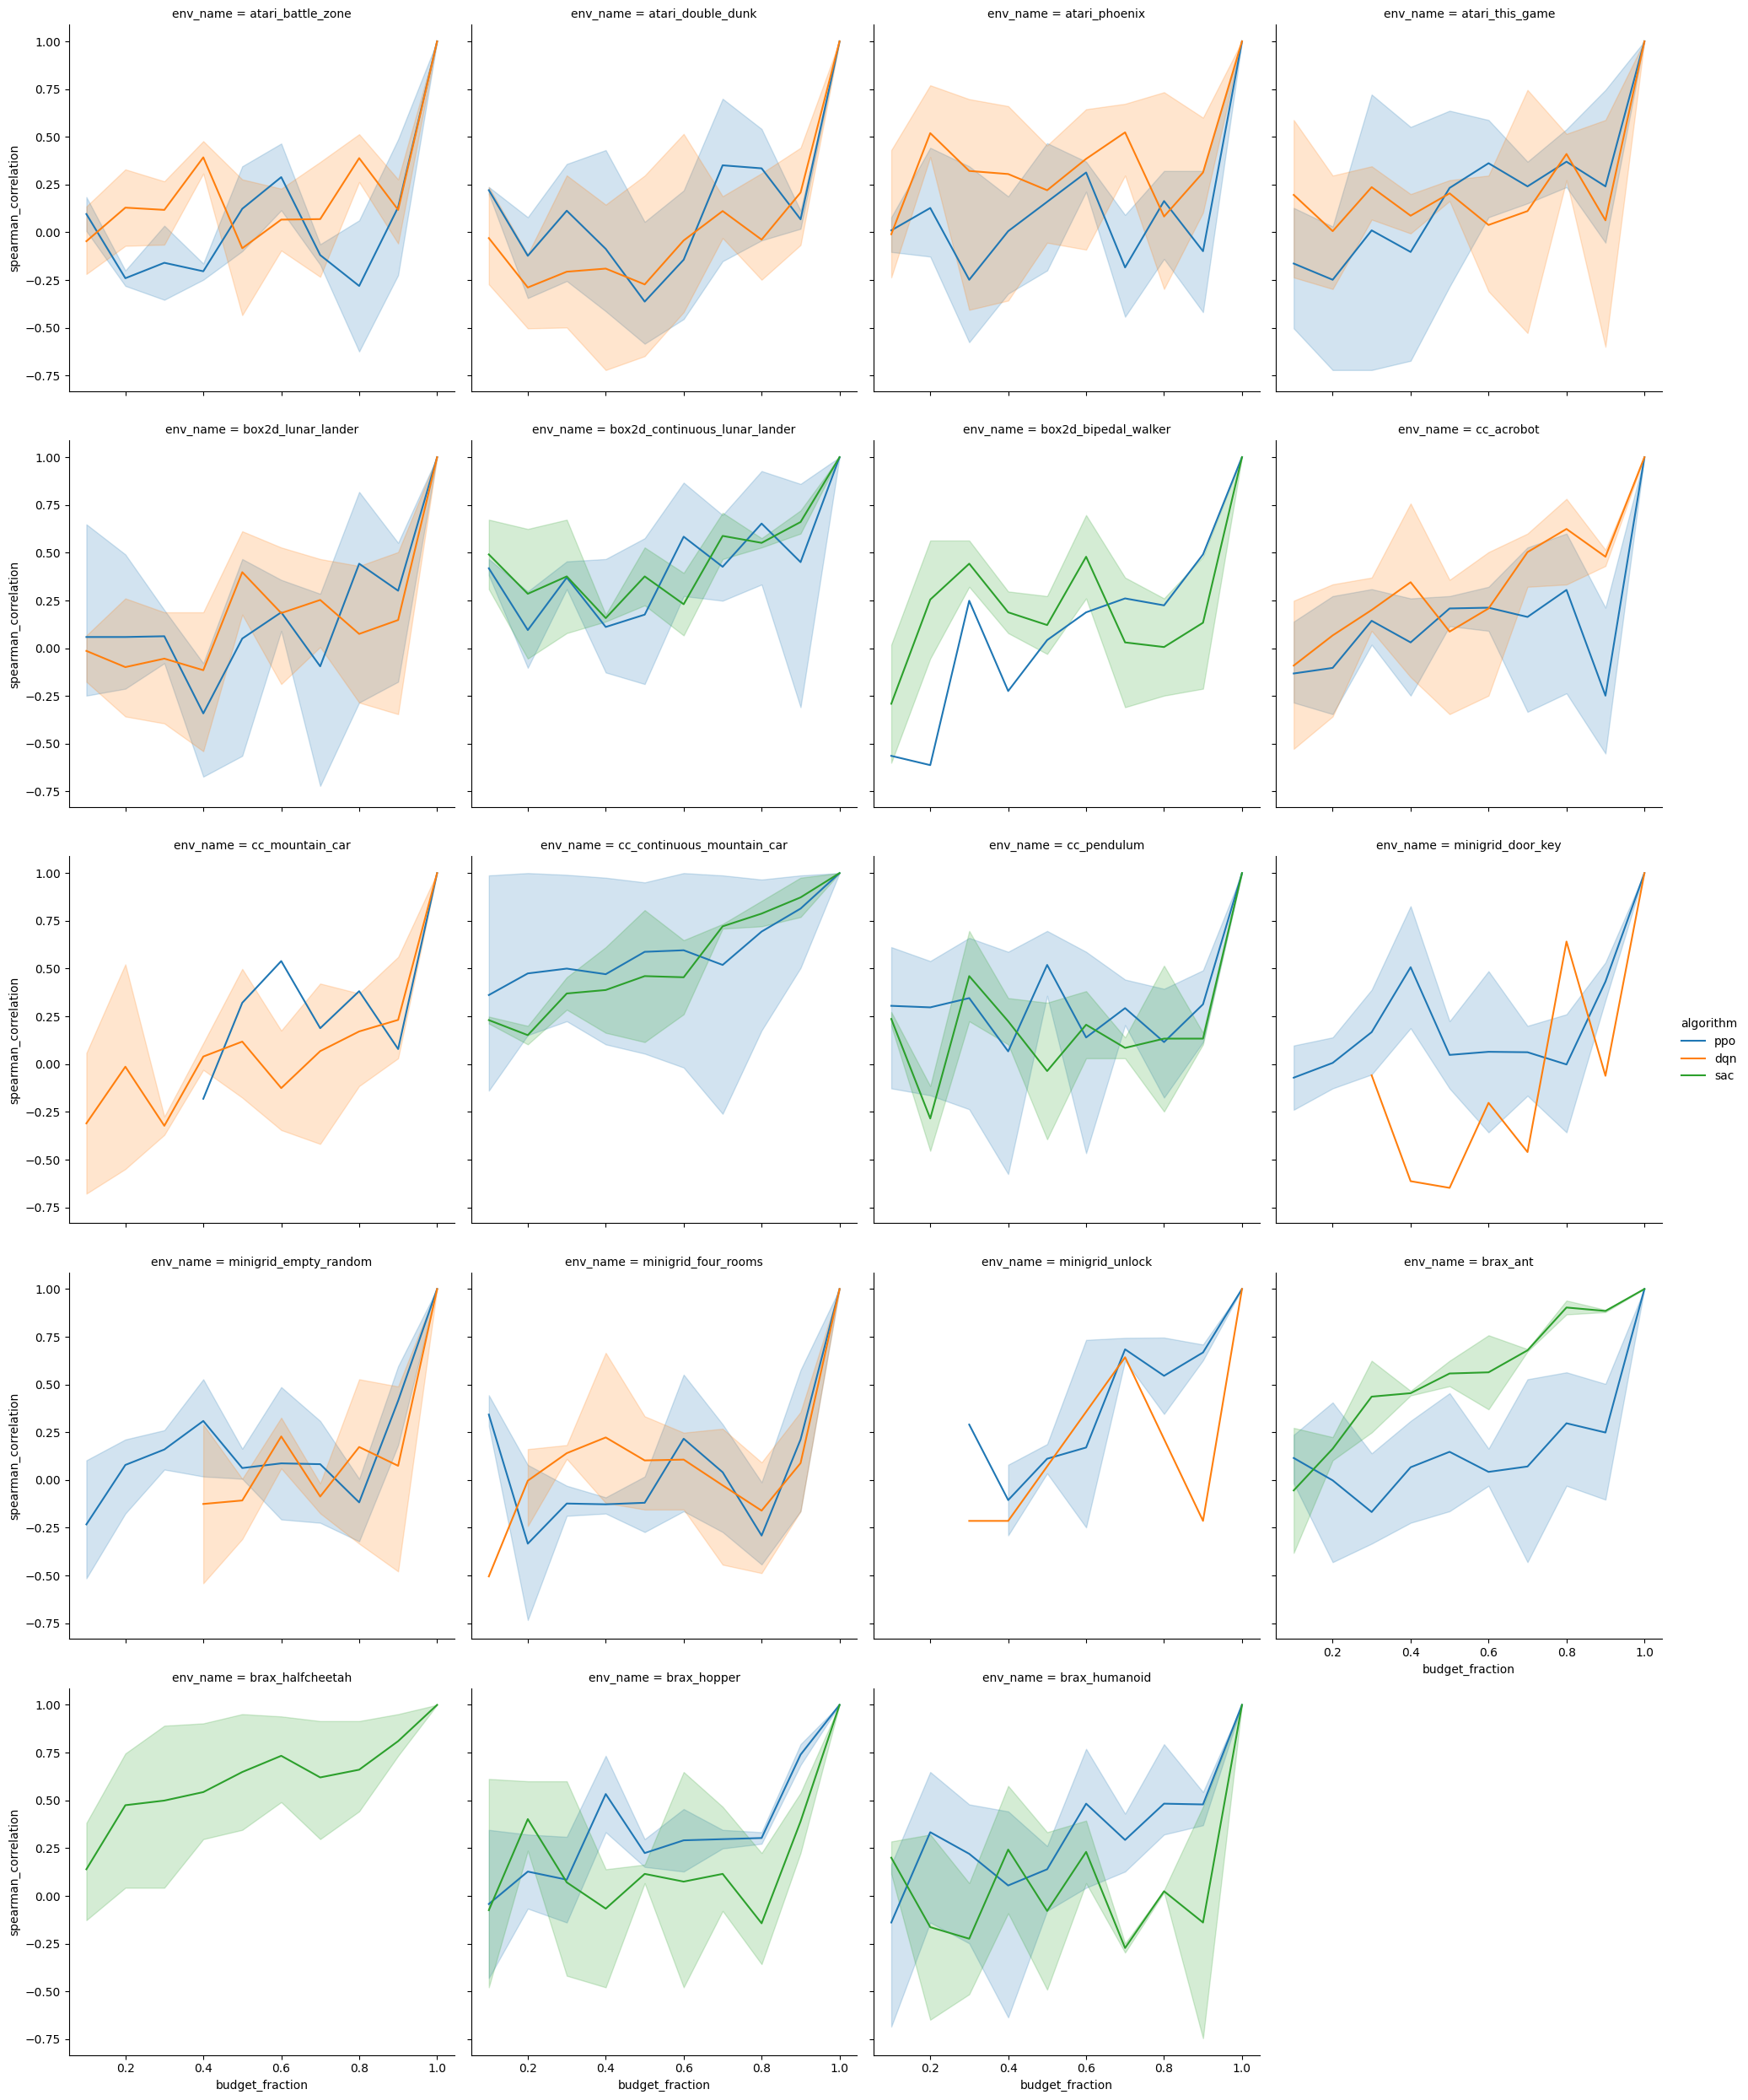

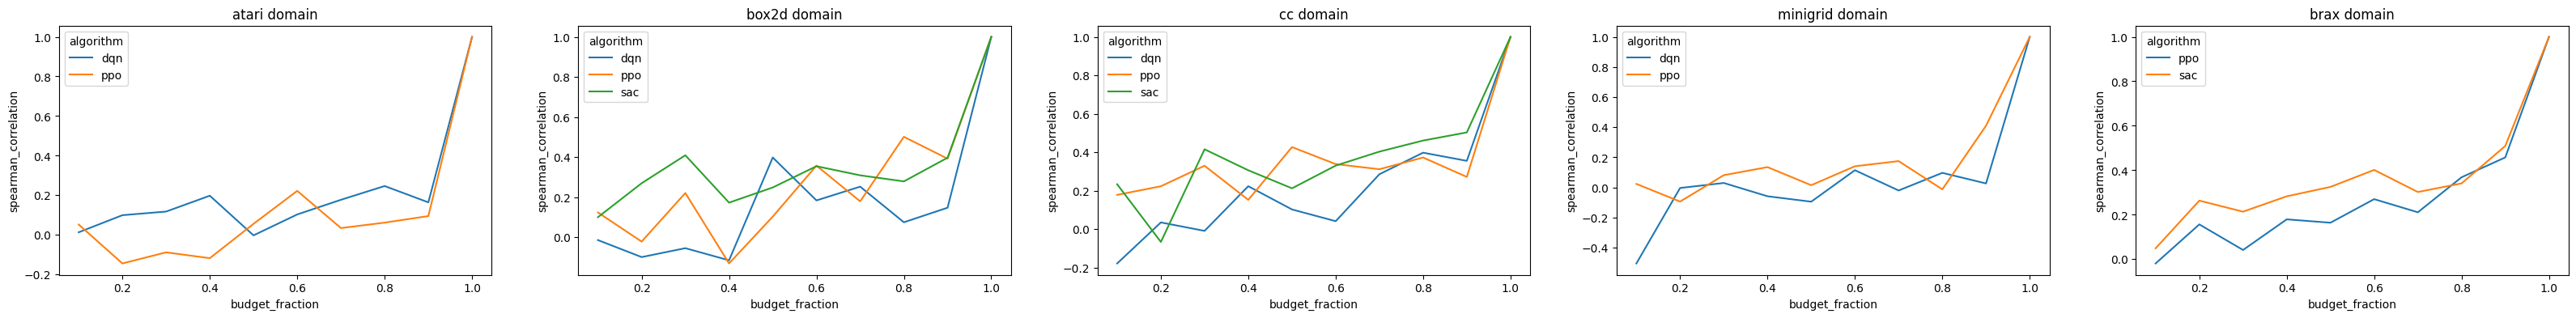

In [9]:
top_10_percent_performance_data = budget_corr_data[budget_corr_data["percentile"] >= 0.9]
sns.lineplot(data=top_10_percent_performance_data, x="budget_fraction", y="spearman_correlation", hue="algorithm")
sns.relplot(data=top_10_percent_performance_data, x="budget_fraction", y="spearman_correlation", hue="algorithm", kind="line", col="env_name", col_wrap=4)

domains = ["atari", "box2d", "cc", "minigrid", "brax"]
fig, ax = plt.subplots(1, len(domains), figsize=(8*len(domains), 4))
for i, domain in enumerate(domains):
    domain_data = top_10_percent_performance_data[top_10_percent_performance_data["env_name"].str.contains(domain)]
    avg_corr = domain_data.groupby(["algorithm", "budget_fraction"])["spearman_correlation"].mean().reset_index()
    sns.lineplot(data=avg_corr, x="budget_fraction", y="spearman_correlation", hue="algorithm", ax=ax[i]).set(title=f"{domain} domain")

In [10]:
n = 0.9
top_cutoff = 256*(1-n)
bottom_cutoff = 256*n
tolerance = 0.02

def rank_with_tolerance(sr, tolerance=0.01+1e-10, method='average'):
    
    vals = pd.Series(sr.unique()).sort_values()
    vals.index = vals
    vals = vals.mask(vals - vals.shift(1) <= tolerance, vals.shift(1))
    
    return sr.map(vals).fillna(sr).rank(method=method)

algorithms = []
environments = []
strict_persistences = []
soft_strict_persistences = []
larger_than_persistences = []
soft_larger_than_persistences = []
top_n_persistences = []
soft_top_n_persistences = []
bottom_n_persistences = []
soft_bottom_n_persistences = []
domains = []
training_steps = []

for algo in algos:
    for env in envs:
        algo_env_data = data[(data["algorithm"] == algo) & (data["env_name"] == env)]
        if algo_env_data.empty:
            continue
        for step in algo_env_data["training_steps"].unique():
            if step == algo_env_data["training_steps"].max():
                continue
            mean_initial_performance = algo_env_data[algo_env_data["training_steps"] == step].groupby("config_id")["performance"].mean()
            initial_performance_ranks = mean_initial_performance.rank(ascending=False)
            soft_initial_performance_ranks = rank_with_tolerance(mean_initial_performance, tolerance=tolerance)
            mean_other_performances = algo_env_data[algo_env_data["training_steps"] > step].groupby(["config_id", "training_steps"])["performance"].mean()
            other_performance_ranks = mean_other_performances.groupby("training_steps").rank(ascending=False)
            soft_other_performance_ranks = mean_other_performances.groupby("training_steps").apply(lambda x: rank_with_tolerance(x, tolerance=tolerance))
            strict_count = 0
            larger_than_count = 0
            top_n_count = 0
            bottom_n_count = 0
            top_n_persistence = 0
            bottom_n_persistence = 0
            soft_strict_count = 0
            soft_larger_than_count = 0
            soft_top_n_count = 0
            soft_bottom_n_count = 0
            soft_top_n_persistence = 0
            soft_bottom_n_persistence = 0
            for config_id in initial_performance_ranks.index:
                initial_rank = initial_performance_ranks[config_id]
                config_other_ranks = other_performance_ranks.xs(config_id, level="config_id")
                soft_initial_rank = soft_initial_performance_ranks[config_id]
                soft_config_other_ranks = soft_other_performance_ranks.xs(config_id, level="config_id")
                if all(config_other_ranks == initial_rank):
                    strict_count += 1
                if all(soft_config_other_ranks == soft_initial_rank):
                    soft_strict_count += 1
                if all(config_other_ranks <= initial_rank):
                    larger_than_count += 1
                if all(soft_config_other_ranks <= soft_initial_rank):
                    soft_larger_than_count += 1
                if initial_rank < top_cutoff:
                    top_n_count += 1
                    if all(config_other_ranks < top_cutoff):
                        top_n_persistence += 1
                if soft_initial_rank < top_cutoff:
                    soft_top_n_count += 1
                    if all(soft_config_other_ranks < top_cutoff):
                        soft_top_n_persistence += 1
                if initial_rank > bottom_cutoff:
                    bottom_n_count += 1
                    if all(config_other_ranks > bottom_cutoff):
                        bottom_n_persistence += 1
                if soft_initial_rank > bottom_cutoff:
                    soft_bottom_n_count += 1
                    if all(soft_config_other_ranks > bottom_cutoff):
                        soft_bottom_n_persistence += 1
                
            strict_persistence = strict_count / len(initial_performance_ranks)
            larger_than_persistence = larger_than_count / len(initial_performance_ranks)
            top_n_persistence = top_n_persistence / top_n_count if top_n_count > 0 else 0
            bottom_n_persistence = bottom_n_persistence / bottom_n_count if bottom_n_count > 0 else 0
            algorithms.append(algo)
            environments.append(env)
            strict_persistences.append(strict_persistence)
            larger_than_persistences.append(larger_than_persistence)
            top_n_persistences.append(top_n_persistence)
            bottom_n_persistences.append(bottom_n_persistence)
            domains.append(env.split("_")[0])
            training_steps.append(step)
            soft_strict_persistences.append(soft_strict_count / len(initial_performance_ranks))
            soft_larger_than_persistences.append(soft_larger_than_count / len(initial_performance_ranks))
            soft_top_n_persistences.append(soft_top_n_persistence / soft_top_n_count if soft_top_n_count > 0 else 0)
            soft_bottom_n_persistences.append(soft_bottom_n_persistence / soft_bottom_n_count if soft_bottom_n_count > 0 else 0)

persistences_df = pd.DataFrame({
    "algorithm": algorithms,
    "environment": environments,
    "strict_persistence": strict_persistences,
    "at_least_better_persistence": larger_than_persistences,
    "top_n_persistence": top_n_persistences,
    "bottom_n_persistence": bottom_n_persistences,
    "domain": domains,
    "training_steps": training_steps,
    "soft_strict_persistence": soft_strict_persistences,
    "soft_at_least_better_persistence": soft_larger_than_persistences,
    "soft_top_n_persistence": soft_top_n_persistences,
    "soft_bottom_n_persistence": soft_bottom_n_persistences
})

<Axes: xlabel='algorithm', ylabel='soft_bottom_n_persistence'>

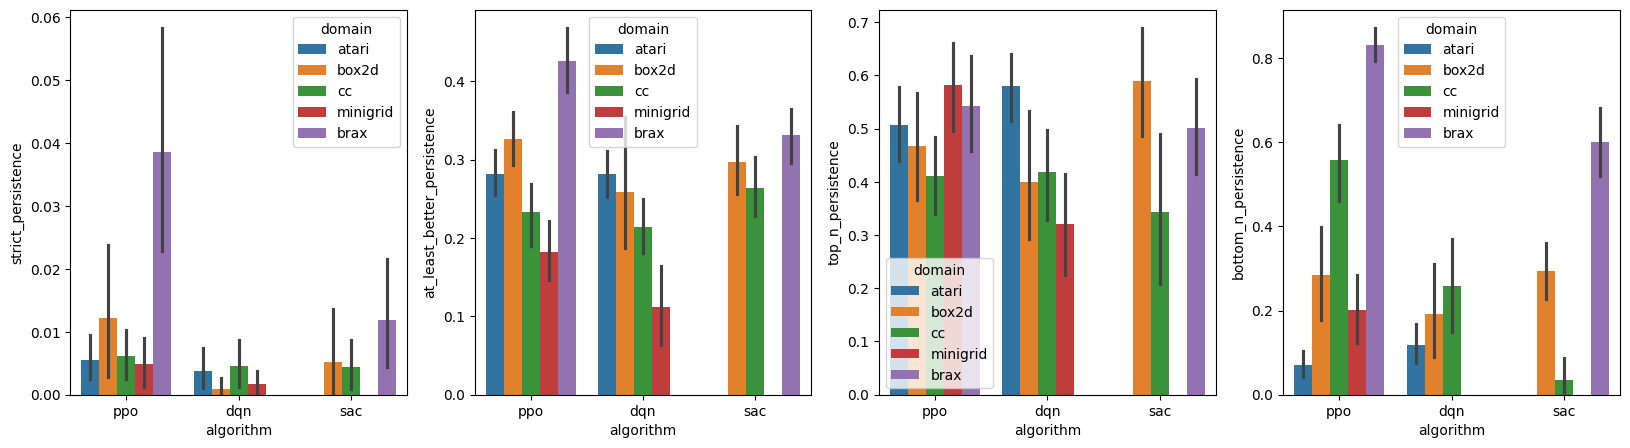

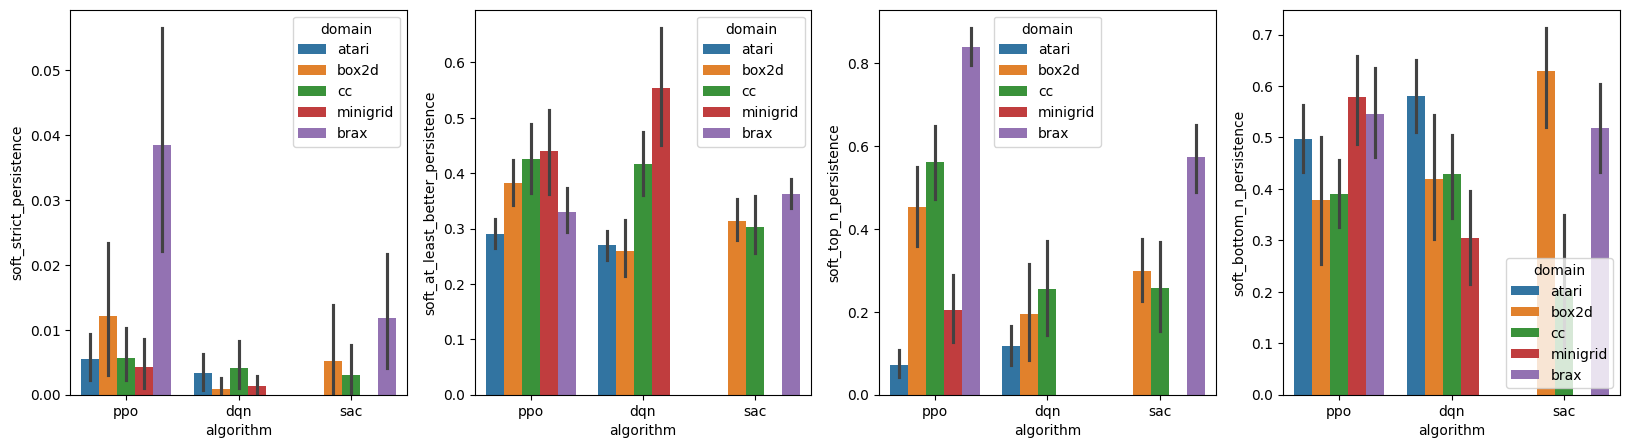

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
sns.barplot(data=persistences_df, x="algorithm", y="strict_persistence", hue="domain", ax=ax[0])
sns.barplot(data=persistences_df, x="algorithm", y="at_least_better_persistence", hue="domain", ax=ax[1])
sns.barplot(data=persistences_df, x="algorithm", y="top_n_persistence", hue="domain", ax=ax[2])
sns.barplot(data=persistences_df, x="algorithm", y="bottom_n_persistence", hue="domain", ax=ax[3])
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
sns.barplot(data=persistences_df, x="algorithm", y="soft_strict_persistence", hue="domain", ax=ax[0])
sns.barplot(data=persistences_df, x="algorithm", y="soft_at_least_better_persistence", hue="domain", ax=ax[1])
sns.barplot(data=persistences_df, x="algorithm", y="soft_top_n_persistence", hue="domain", ax=ax[2])
sns.barplot(data=persistences_df, x="algorithm", y="soft_bottom_n_persistence", hue="domain", ax=ax[3])

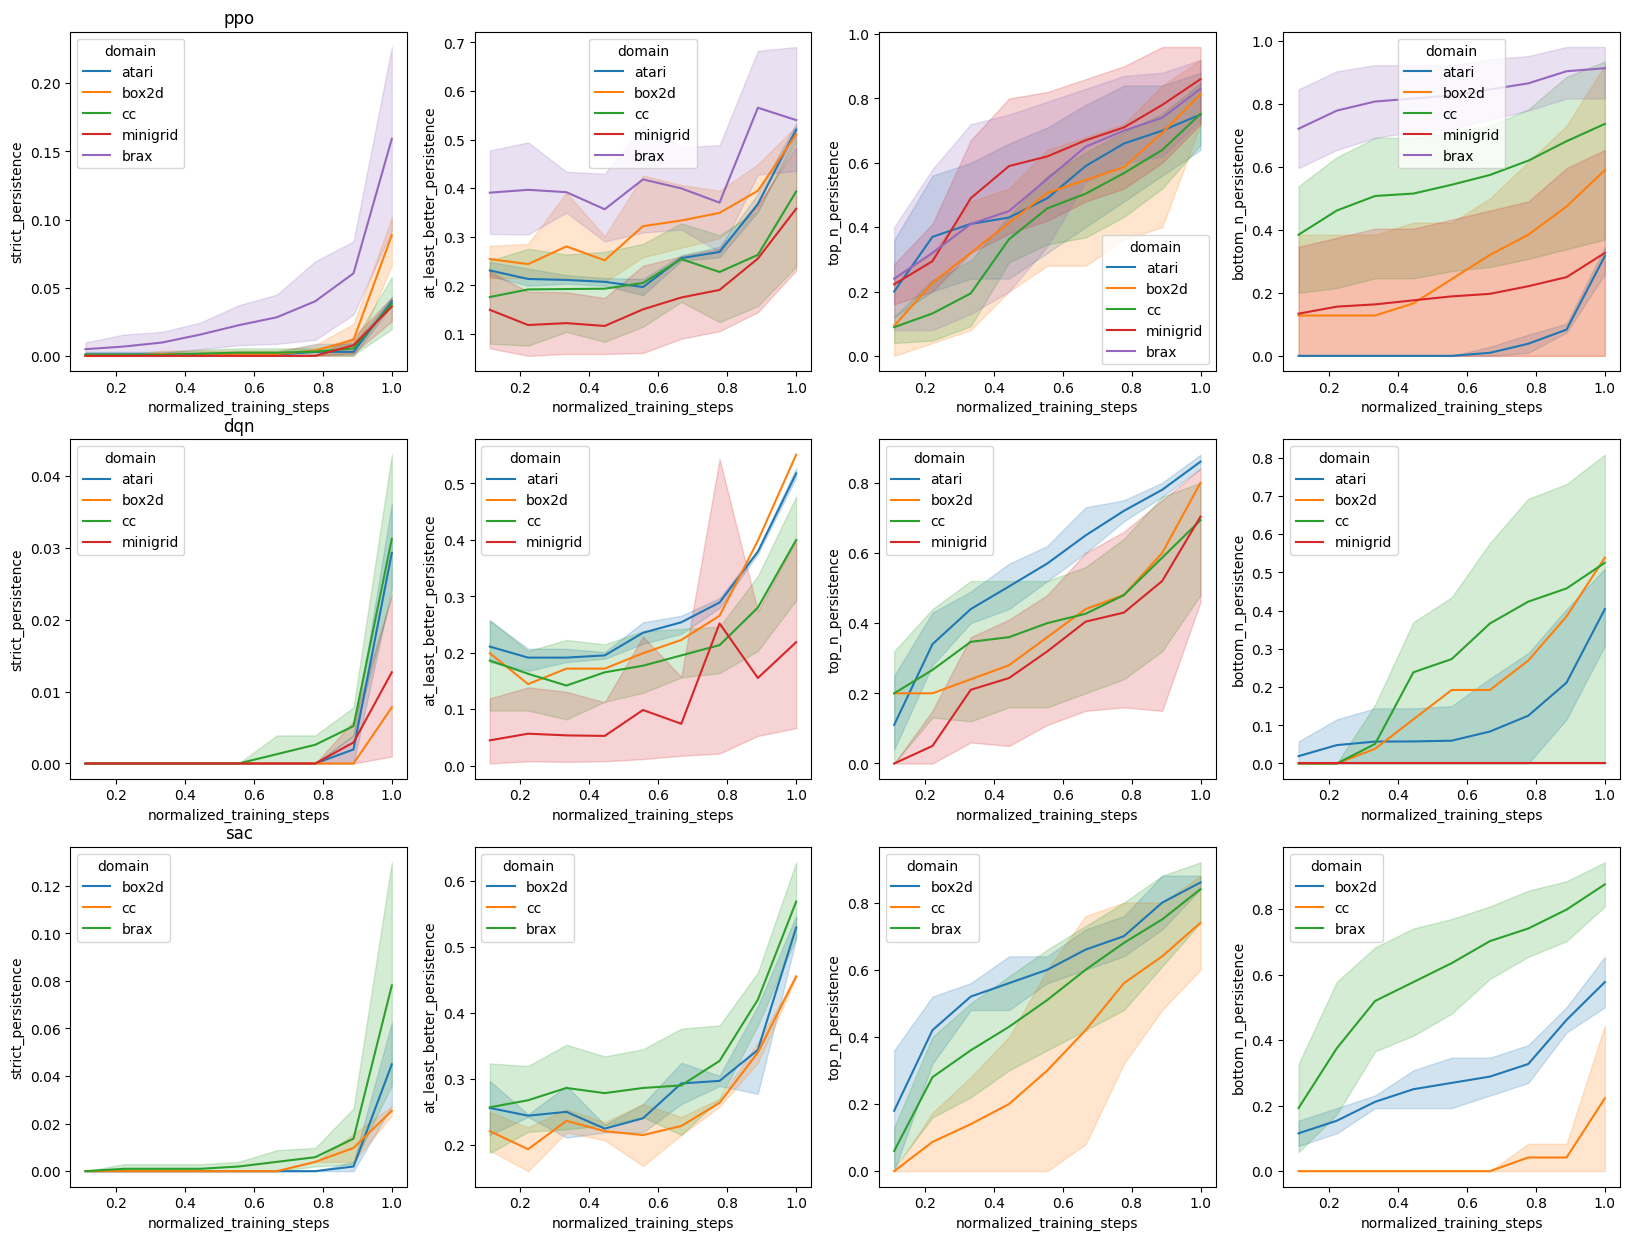

In [10]:
persistences_df["normalized_training_steps"] = persistences_df.groupby(["algorithm", "environment"])["training_steps"].transform(lambda x: x / x.max())
fig, ax = plt.subplots(3, 4, figsize=(20, 15))
for i, algorithm in enumerate(algos):
    sns.lineplot(data=persistences_df[persistences_df["algorithm"]==algorithm], x="normalized_training_steps", y="strict_persistence", hue="domain", ax=ax[i][0])
    sns.lineplot(data=persistences_df[persistences_df["algorithm"]==algorithm], x="normalized_training_steps", y="at_least_better_persistence", hue="domain", ax=ax[i][1])
    sns.lineplot(data=persistences_df[persistences_df["algorithm"]==algorithm], x="normalized_training_steps", y="top_n_persistence", hue="domain", ax=ax[i][2])
    sns.lineplot(data=persistences_df[persistences_df["algorithm"]==algorithm], x="normalized_training_steps", y="bottom_n_persistence", hue="domain", ax=ax[i][3])
    ax[i][0].set_title(algorithm)

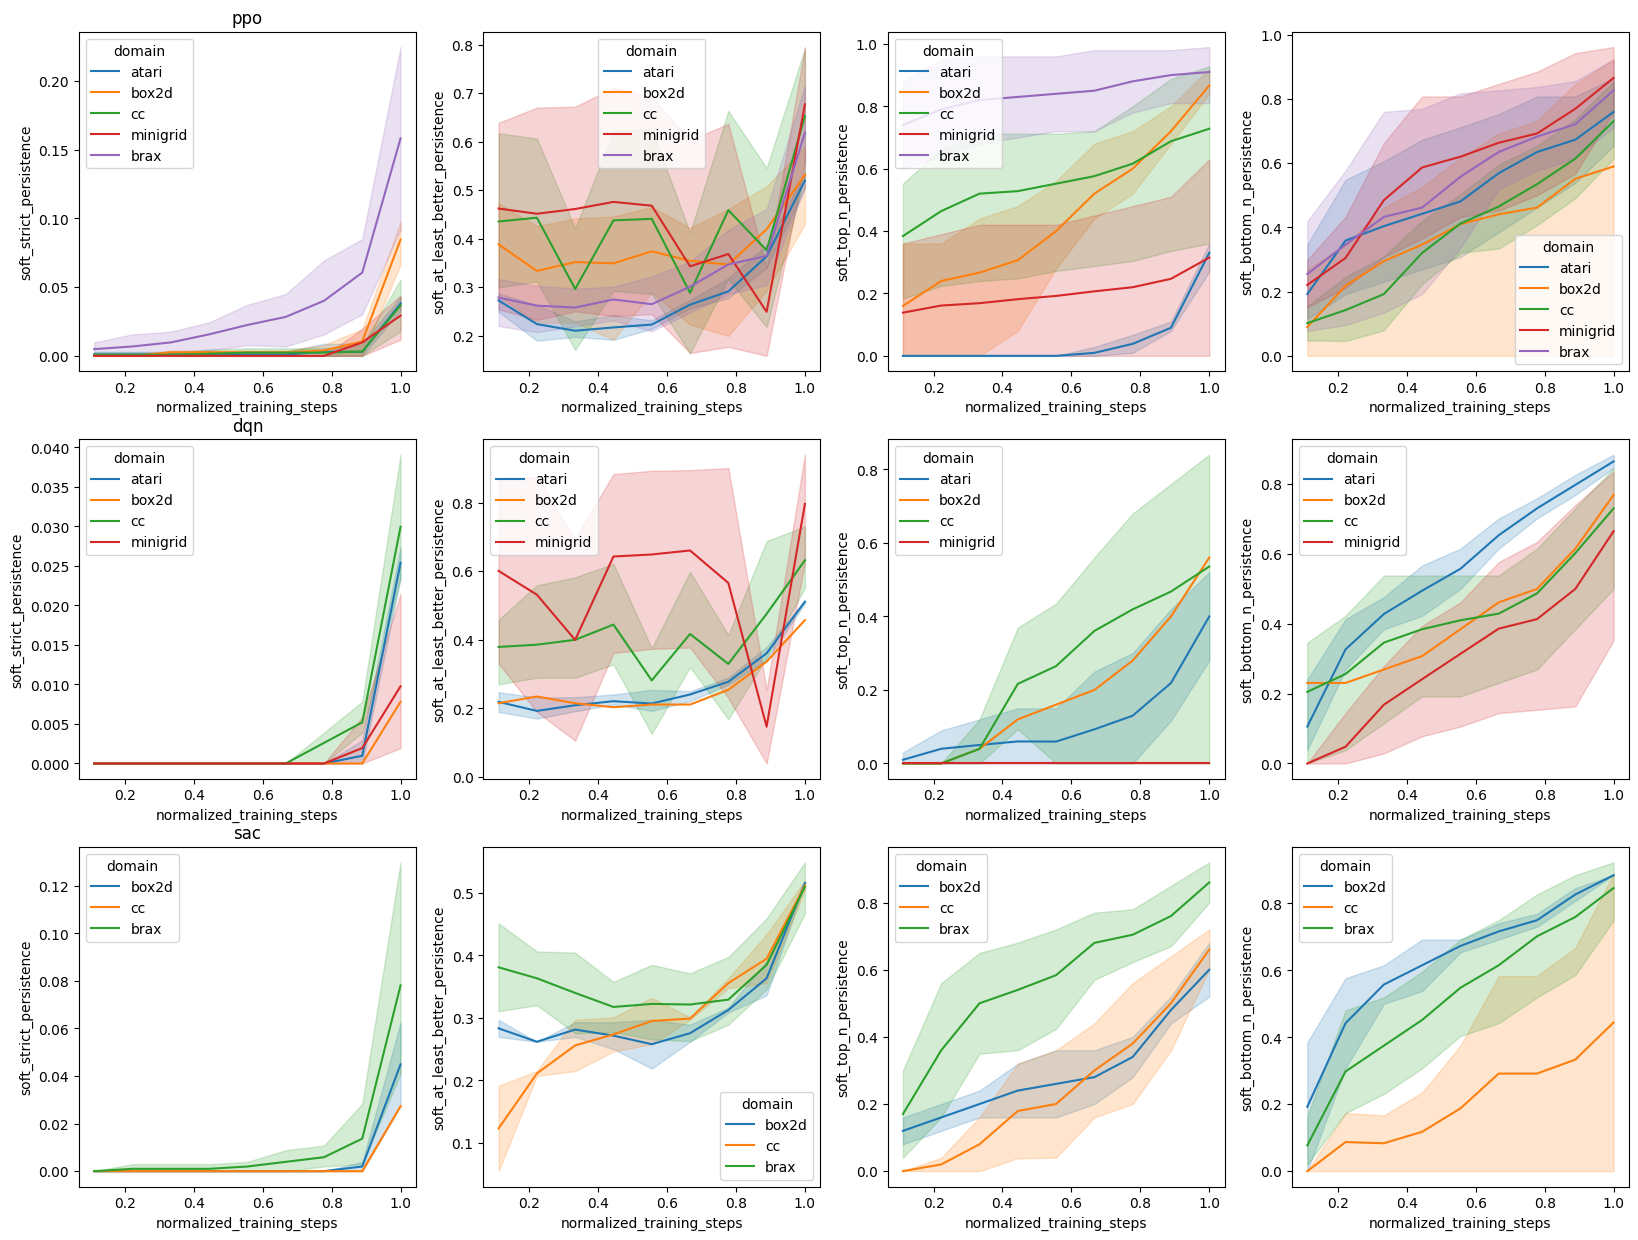

In [11]:
persistences_df["normalized_training_steps"] = persistences_df.groupby(["algorithm", "environment"])["training_steps"].transform(lambda x: x / x.max())
fig, ax = plt.subplots(3, 4, figsize=(20, 15))
for i, algorithm in enumerate(algos):
    sns.lineplot(data=persistences_df[persistences_df["algorithm"]==algorithm], x="normalized_training_steps", y="soft_strict_persistence", hue="domain", ax=ax[i][0])
    sns.lineplot(data=persistences_df[persistences_df["algorithm"]==algorithm], x="normalized_training_steps", y="soft_at_least_better_persistence", hue="domain", ax=ax[i][1])
    sns.lineplot(data=persistences_df[persistences_df["algorithm"]==algorithm], x="normalized_training_steps", y="soft_top_n_persistence", hue="domain", ax=ax[i][2])
    sns.lineplot(data=persistences_df[persistences_df["algorithm"]==algorithm], x="normalized_training_steps", y="soft_bottom_n_persistence", hue="domain", ax=ax[i][3])
    ax[i][0].set_title(algorithm)

In [64]:
# budget correlation, but budget is number of envs evaluated for choosing best config overall and per domain
environments = []
algorithms = []
budgets = []
correlations_to_overall_best = []
correlations_to_domain_best = []
performance_subset = []
performance_full = []
domains = []
config_ids = []
for algo in algos:
        subset = data[data["algorithm"] == algo]
        for config_id in subset["config_id"].unique():
            config_data = subset[subset["config_id"] == config_id]
            config_data = config_data.groupby("env_name").apply(lambda x: x[x['training_steps'] == x['training_steps'].max()]).reset_index(drop=True)
            config_data["performance"] = config_data.groupby("env_name")["performance"].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
            max_domain_size = np.max([[sum(1 for e in envs if e.split("_")[0] == domain) for env in envs] for domain in ["atari", "cc", "box2d", "minigrid", "brax"]])
            for n_envs in range(1, max_domain_size+1):
                n_envs_performances = []
                full_domain_performances = []
                for domain in ["atari", "cc", "box2d", "minigrid", "brax"]:
                    domain_size = sum(1 for e in envs if e.split("_")[0] == domain)
                    if n_envs > domain_size:
                        continue
                    domain_envs = [e for e in envs if e.split("_")[0] == domain]
                    domain_config_data = config_data[config_data["env_name"].isin(domain_envs)]
                    all_envs_performance = domain_config_data["performance"].mean()
                    n_envs_performance_domain = []
                    for other_envs in itertools.combinations(domain_envs, n_envs):
                        selected_domain_envs = list(other_envs)
                        permuted_domain_config_data = config_data[config_data["env_name"].isin(selected_domain_envs)]
                        mean_budget_domain_performance = permuted_domain_config_data["performance"].mean()
                        if np.isnan(mean_budget_domain_performance):
                            continue
                        n_envs_performance_domain.append(mean_budget_domain_performance)
                    if np.isnan(np.mean(n_envs_performance_domain)):
                        continue
                    n_envs_performances.append(np.mean(n_envs_performance_domain))
                    full_domain_performances.append(all_envs_performance)
                
                    if len(n_envs_performance_domain) < 1:
                        continue
                    
                    #spearman_corr_domain = stats.pearsonr(n_envs_performance_domain, [all_envs_performance]*len(n_envs_performance_domain)).correlation
                    environments.append(env)
                    algorithms.append(algo)
                    budgets.append(n_envs)
                    performance_subset.append(np.mean(n_envs_performance_domain))
                    performance_full.append(all_envs_performance)
                    #correlations_to_domain_best.append(spearman_corr_domain)
                    config_ids.append(config_id)
                    domains.append(domain)


budget_corr_data = pd.DataFrame({
    "env_name": environments,
    "algorithm": algorithms,
    "budget_fraction": budgets,
    #"spearman_corr_domain": correlations_to_domain_best,
    "performance_subset": performance_subset,
    "performance_full_domain": performance_full,
    "config_id": config_ids,
    "domain": domains
})
budget_corr_data["error"] = np.abs(budget_corr_data["performance_subset"] - budget_corr_data["performance_full_domain"])

/var/folders/yc/_2wjgdhd4px91396bq5wm7kr0000gn/T/ipykernel_69390/3568156552.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  config_data = config_data.groupby("env_name").apply(lambda x: x[x['training_steps'] == x['training_steps'].max()]).reset_index(drop=True)
/var/folders/yc/_2wjgdhd4px91396bq5wm7kr0000gn/T/ipykernel_69390/3568156552.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  config_data = config_dat

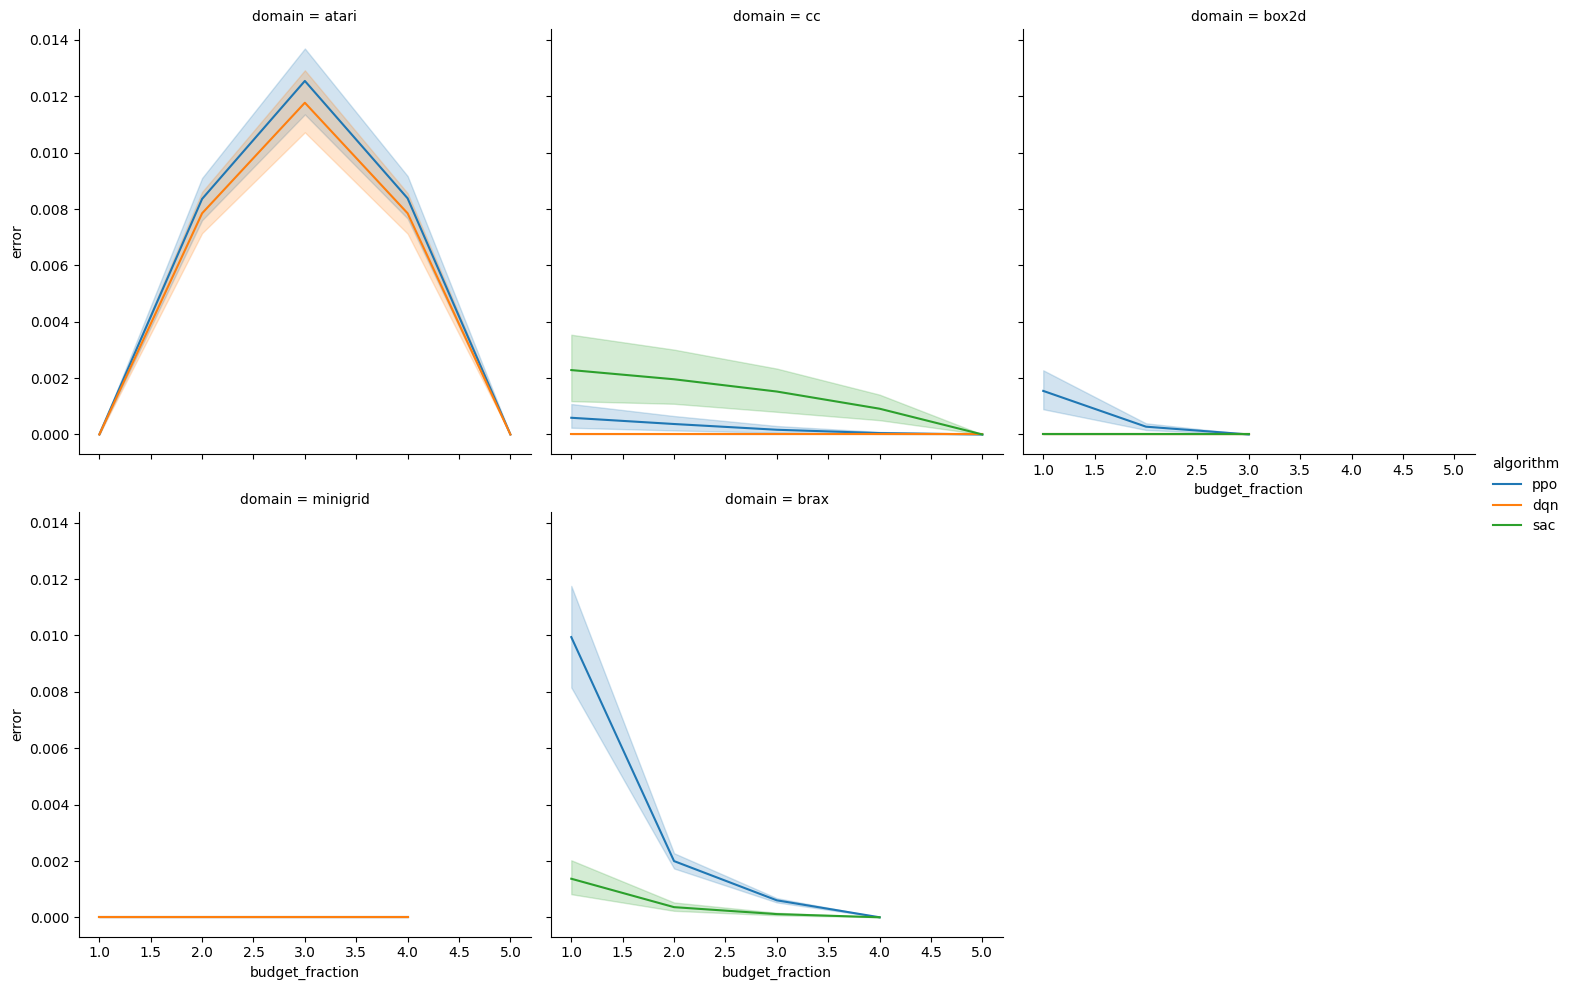

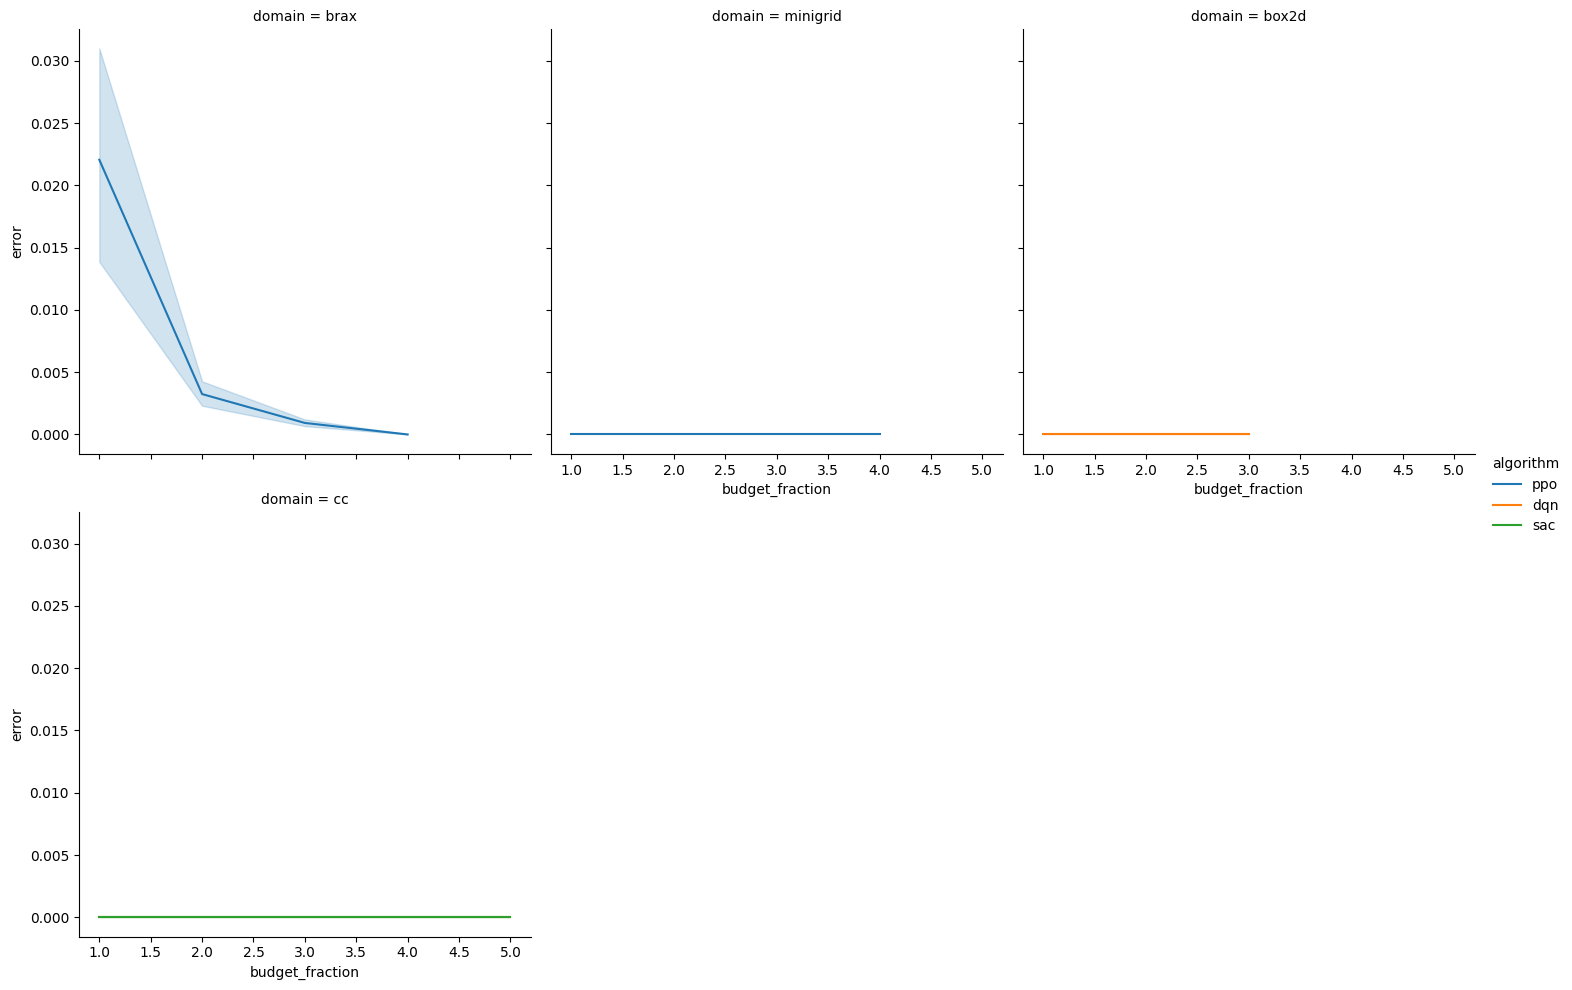

In [65]:
sns.relplot(data=budget_corr_data, x="budget_fraction", y="error", hue="algorithm", kind="line", col="domain", col_wrap=3)
sns.relplot(data=budget_corr_data[budget_corr_data["performance_full_domain"]>0.8], x="budget_fraction", y="error", hue="algorithm", kind="line", col="domain", col_wrap=3)